# Lab 1-2
This lab assignment covers Week 1 and 2 (Lectures 1 - 5):
1. Data
2. Linear Regression 1 (Correlation and Ordinary Least Squares)
3. Train Test Splitting
4. Linear Regression 2 (Multiple Regression and Regularization)
5. Classification Errors

### Submission And Assignment Instructions
Submit your `Lab1-2_lastname_firstname.pdf` file on canvas with your answers clearly marked (✅) and code commented. Skeleton code and/or comments are provided throughout to help you.

Formatting Notes:
- ❓Questions you must answer or tasks are marked with a "❓"
- ✅ Answers you should give are marked with "✅ Answer:"
- *Helpful hints are usually given in italics*
- Code you need to write is marked with `## ❓YOUR CODE HERE`
  - ⭐ Bonus questions are marked with a "⭐"
  - 🍓 Bonus answers are marked with a "🍓"

**Please don't erase ANY of these markings!** They're to help the TAs find your answers and code as much as they're to help you find the questions.

## Section 1: Math!

Answers may be submitted as Latex typeset equations OR inserted as pictures of your handwritten notes. For the later, please ensure you take a clear scan/picture of your readable work. If we can not read your writing, we might have to deduct points for incomplete answers.



### 1.1: Derivation of the Ordinary Least Squares Estimator with Calculus

In the lecture you were introduced to the OLS equations, let's find out where these equations come from!


❓1.1.1 The mean squared error (MSE) function for a simple linear model can be expressed as $E(\beta_0, \beta_1) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i)^2$. Take the partial derivative of $E$ wrt $\beta_0$.

>> ✅Answer: 

❓1.1.2 Take the partial derivative of $E$ wrt $\beta_1$.

>> ✅ Answer:

❓1.1.3 Set both partial derivatives equal to 0 and solve for the optimal parameter values of $\beta_0$ and $\beta_1$. You must show your work.

      

✅ Answer:

### ⭐ 1.2: Bonus - Linear Algebra Notation for Multiple Linear Regression

We can rewrite the OLS equations above like this:

\begin{align}
  \hat Y &= \begin{pmatrix}  
             1 & x_1 \\
             1 & x_2 \\
             \vdots & \vdots \\
             1 & x_n
          \end{pmatrix} \begin{pmatrix}
                               \beta_0 \\
                               \beta_1
                              \end{pmatrix} \\ 
         &= \begin{pmatrix}  
             1 & \mid \\
             \vdots & \vec{x} \\
             1 & \mid
          \end{pmatrix} \begin{pmatrix}
                               \beta_0 \\
                               \beta_1
                              \end{pmatrix} \\ 
         &= X \vec{\beta}
\end{align}

⭐ 1.2.1 **Why do we need a column of 1s in the $X$ matrix above? (one sentence)** \\

🍓 Answer: The column of 1s in the X matrix above ensures that the β_0 constant is added to the equation.

⭐ 1.2.2 Imagine we now have 2 independent variables, which we'll call $\vec x_1$ and $\vec x_2$, that we wish to use to predict $\vec y$. We will also fit a new parameter, $\beta_2$ to represent the "slope" from the $X_2$ predictor. Write the new equations for $\hat Y$ in matrix form, with $\vec \beta = \begin{pmatrix}\beta_0 \\ \beta_1 \\ \beta_2 \end{pmatrix}$.

🍓 Answer:

⭐ 1.2.3 Write new equations for $\vec e$, the vector of residuals in matrix form, with $\vec \beta = \begin{pmatrix}\beta_0 \\ \beta_1 \\ \beta_2 \end{pmatrix}$.

🍓 Answer:

## Section 2: Brain and Body Weights

### 2.1: Loading the data
Use the provided code block to upload the file to collab.

In [204]:
#commented below out as this was done in VSCode
# load local file "Lab01_Data_01_brains.txt"
#from google.colab import files

#uploaded = files.upload()

#for fn in uploaded.keys():
  #print('User uploaded file "{name}" with length {length} bytes'.format(
      #name=fn, length=len(uploaded[fn])))

❓2.1.1 Write code to read in your uploaded file as a pandas dataframe and visualize the first 5 rows.

In [205]:
# import numpy and pandas to prep your workspace
import numpy as np
import pandas as pd

## ❓ YOUR CODE HERE
# Read data in as a pandas df
df = pd.read_csv('Lab01_Data_01_brains.txt', sep='\t')

# visualize first five rows using data.head()
df.head(5)

,Index,Body.Weight,Brain.Weight
0,1,3.385,44.5
1,2,0.480,15.5
2,3,1.350,8.1
3,4,465.000,423.0
4,5,36.330,119.5


❓2.1.2 Identify and describe the variables in this dataframe. Are these categorical? Ordinal? Integer? Logical?

✅Answer: There are 3 variables, namely, index, body weight, and brain weight. Index is a categorical variable (not integer) because even though it consists of whole numbers, it acts as a unique identifier or label rather than a measurable quantity or count. Both brain and body weight are continuous variables.

### 2.2: Data Exploration & Visualization


❓ 2.2.1 Let's predict brain weight from body weight. Visualize brain weight and body weight on a plot, with the independent variable on the x-axis. Be sure to label all parts of your figure (axis labels with units and title).

Text(0.5, 1.0, 'Mammalian Brain Weight v. Body Weight')

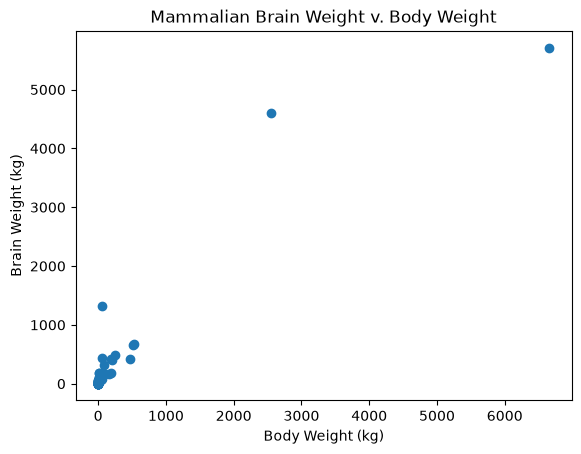

In [206]:
# first import matplotlib
from matplotlib import pyplot as plt

##❓YOUR CODE HERE (to plot)
plt.figure()
plt.scatter(df["Body.Weight"], df["Brain.Weight"])
plt.xlabel("Body Weight (kg)")
plt.ylabel("Brain Weight (kg)")
plt.title("Mammalian Brain Weight v. Body Weight")

❓2.2.2 What are the assumptions for linear regression? Describe each assumption with <1 sentence.

✅Answer: LINE!
There is a linear relationship between x and y. The residuals are independent and normally distributed. For any value of x, equal variance of the residuals.

### 2.3: Transformation

❓2.3.1 Transform the data to try to correct the linearity assumption and replot. Label your plot appropriately (include axis labels, title, units).

Text(0.5, 1.0, 'Mammalian Brain Weight v. Body Weight')

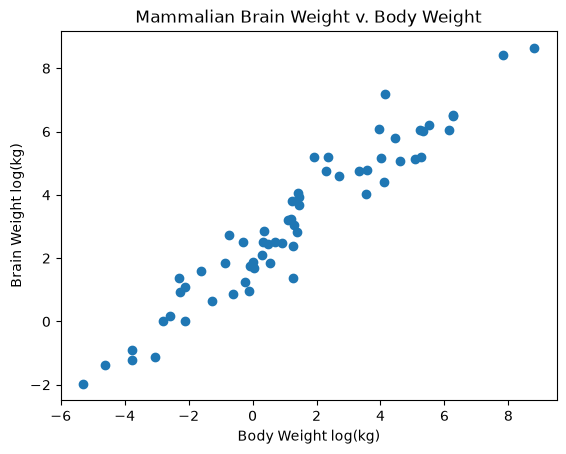

In [207]:
##❓YOUR CODE HERE
# create new columns of log-scaled values in your pd df using data.assign()
logScaled = df.assign(logBody = np.log(df["Body.Weight"]), logBrain = np.log(df["Brain.Weight"]))
# visualize the first 5 rows of the new df
df.head(5)
# visualize the transformed data
plt.figure()
plt.scatter(logScaled["logBody"], logScaled["logBrain"])
plt.xlabel("Body Weight log(kg)")
plt.ylabel("Brain Weight log(kg)")
plt.title("Mammalian Brain Weight v. Body Weight")

❓2.3.2 Have we satisfied these assumptions for the relationship between brain and body weight? What assumption(s) did the transformation help satisfy? *Your plot should qualitatively answer this question, you don't need to perform statistical tests or analysis beyond visual inspection.*

✅ Answer: Yes, visually, there is a linear relationship between x and y. Additionally, the errors seem to be independent & normally distributed and equal variance of the residuals for each x value.

### 2.4: A Simple Linear Model

❓2.4.1 Calculate the intercept and slope of a line of best fit on the transformed data using the formulas you derived above (also in the slides from class!)

In [208]:
##❓YOUR CODE HERE

# calculate slope
xAvg = np.mean(logScaled["logBody"])
yAvg = np.mean(logScaled["logBrain"])
num = np.sum((logScaled["logBody"] - xAvg) * (logScaled["logBrain"] - yAvg))
denom = np.sum((logScaled["logBody"] - xAvg) ** 2)
m = num / denom
# be nice to your TAs
# try to print outputs from code labelled and easy to read
# this is an example if you name your slope variable m
print("Slope: ", m)

Slope:  0.7516859362419007


In [209]:
## ❓YOUR CODE HERE
# calculate and display intercept
b = yAvg - (m * xAvg)
# display and be nice to the TAs
print("Intercept: ", b)

Intercept:  2.134788676764636


### 2.5: Assessing the Model
### Visualizing Error
To do linear regression, we assume that there is a linear relationship between $x$ and $y$, and we assume that the errors in $y$ are normally and equally distributed at each $x$ value. One of the easiest ways to visualize whether these assumptions hold in our model is to make a residuals plot, which displays the errors of the model (the residuals, $y - \hat y$) against the x-values themselves.

❓2.5.1 Calculate residuals and add them to your pandas dataframe. Make a residuals plot and label appropriately (include axis labels, units, plot title)

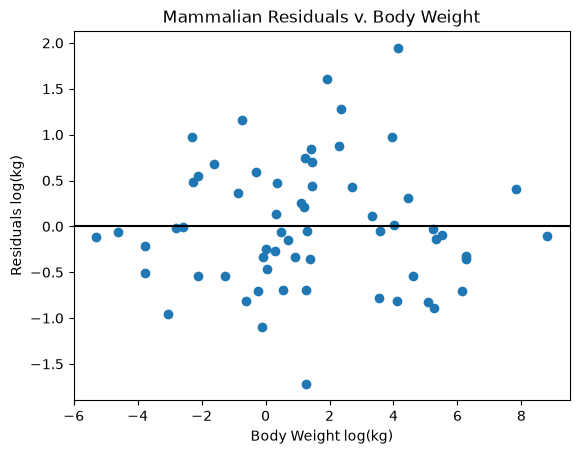

In [210]:
##❓YOUR CODE HERE
# calculate residuals for each observation
yPred = m * logScaled["logBody"] + b
res = logScaled["logBrain"] - yPred

# Make a residuals plot using matplotlib
plt.figure()
plt.scatter(logScaled["logBody"], res)
plt.xlabel("Body Weight log(kg)")
plt.ylabel("Residuals log(kg)")
plt.title("Mammalian Residuals v. Body Weight")
plt.axhline(0, linestyle = "-", color = "black")

❓2.5.2 Briefly interpret your residuals plot. Do you see any patterns? What do the patterns (or lack thereof) imply about your model?

✅ Answer: The random pattern of the residual plot is supportive of our previous assumption that the data is independent and normally distributed.

### 2.6 Visualize Model

❓2.6.1 Add a line of best fit to your log-scaled data plot from earlier.

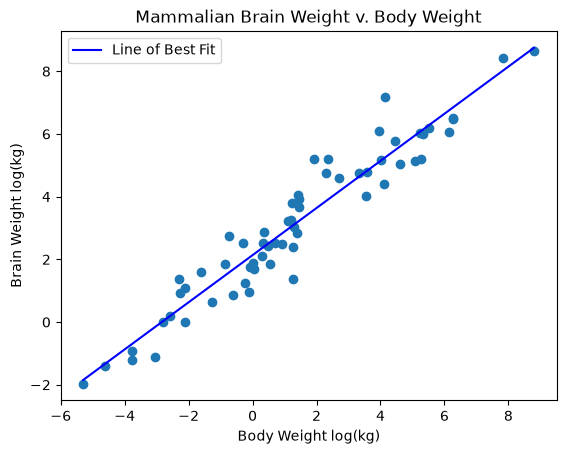

In [211]:
##❓YOUR CODE HERE
# visualize the transformed data
plt.figure()
plt.scatter(logScaled["logBody"], logScaled["logBrain"])
plt.xlabel("Body Weight log(kg)")
plt.ylabel("Brain Weight log(kg)")
plt.title("Mammalian Brain Weight v. Body Weight")
x = np.linspace(min(logScaled["logBody"]), max(logScaled["logBody"]), 100)
plt.plot(x, m*x + b, color="blue", label="Line of Best Fit")

# remember to add a legend
plt.legend()

### ⭐ 2.7 Bonus - Quantitative Error Assessments

Please do this *after* finishing the required assignment.

⭐ 2.7.1 Calculate $R^2$ using the equation from class.

In [212]:
##⭐ YOUR CODE HERE
# calculate slope
xAvgOG = np.mean(df["Body.Weight"])
yAvgOG = np.mean(df["Brain.Weight"])
numOG = np.sum((df["Body.Weight"] - xAvgOG) * (df["Brain.Weight"] - yAvgOG))
denomOG = np.sum((df["Body.Weight"] - xAvgOG) ** 2)
mOG = numOG / denomOG
# calculate y-intercept
bOG = yAvgOG - mOG * xAvgOG
# calculate residuals for each observation
yPredOG = mOG * df["Body.Weight"] + bOG
resOG = df["Brain.Weight"] - yPredOG
# Calculate and display R2
SSres = np.sum(resOG ** 2)
SStot = np.sum((np.mean(df["Brain.Weight"]) - df["Brain.Weight"]) ** 2)
R2 = 1 - SSres / SStot
print("Coefficient of determination: ", R2,
      "\nSSres: ", SSres,
      "\nSStot: ", SStot)

# Calculate and display R2 for the log model
SSres_ln = np.sum(res ** 2)
SStot_ln = np.sum((np.mean(logScaled["logBrain"]) - logScaled["logBrain"]) ** 2)
R2_ln = 1 - SSres_ln / SStot_ln
print("Coefficient of determination for the natural log model: ", R2_ln,
      "\nSSres: ", SSres_ln,
      "\nSStot: ", SStot_ln)

Coefficient of determination:  0.8726620843043331 
SSres:  6722239.055504983 
SStot:  52790553.534509696
Coefficient of determination for the natural log model:  0.9207837169027255 
SSres:  28.92271042146065 
SStot:  365.11067283912723


⭐ 2.7.2 Explain what you calculated and how it connects to the interpretation of $R^2$. (What’s the total sum of squared errors? Why do we need to use it?)

🍓:

⭐ 2.7.3 Does it matter if we calculate $R^2$ from the log-scaled data or from the raw (untransformed) data of body/brain weights? Re-calculate $R^2$ from the untransformed data and estimates of brain weight from your log model and display it. Does this estimate match what you calculated above? Why or why not?

**Note**: You would need to compute $R^2$ in the space of untransformed data

In [213]:
##⭐ YOUR CODE HERE
# recalculate some of the quantities you found above (SSres, SStot, R^2)
# and compare to what you had before
resNew = np.sum(np.exp(logScaled["logBrain"]) - np.exp(yPred))
SSresNew = np.sum(resNew ** 2)
SStotNew = np.sum((np.mean(np.exp(logScaled["logBrain"])) - np.exp(logScaled["logBrain"])) ** 2)
R2New = 1 - SSresNew / SStotNew
print("Transformed raw coefficient of determination: ", R2New,
"Transformed raw r\nSSres: ", SSresNew,
"Transformed raw\nSStot: ", SStotNew)

# doing the same for the natural log model
resNew_ln = np.sum(np.log(np.exp(logScaled["logBrain"])) - np.log(np.exp(yPred)))
SSresNew_ln = np.sum(resNew_ln ** 2)
SStotNew_ln = np.sum((np.log(np.mean(np.exp(logScaled["logBrain"]))) - np.log(np.exp(logScaled["logBrain"]))) ** 2)
R2New_ln = 1 - SSresNew / SStotNew
print("Transformed raw coefficient of determination: ", R2New_ln,
"Transformed raw r\nSSres: ", SSresNew_ln,
"Transformed raw\nSStot: ", SStotNew_ln)

Transformed raw coefficient of determination:  0.9805124876875203 Transformed raw r
SSres:  1028756.5619863768 Transformed raw
SStot:  52790553.53450962
Transformed raw coefficient of determination:  0.9805124876875203 Transformed raw r
SSres:  2.9996435921028974e-28 Transformed raw
SStot:  754.3868511235979


🍓: 

⭐ 2.7.4 Calculate MSE and RMSE explicitly and display their values.


In [214]:
##⭐YOUR CODE HERE
# calculate MSE and RMSE
MSE = np.sum(resOG ** 2) / len(resOG)
RMSE = np.sqrt(MSE)

# display MSE and RMSE
print("MSE: ", MSE, "\nRMSE: ", RMSE)

# doing the same for ln
# calculate MSE and RMSE
MSE_ln = np.sum(res ** 2) / len(res)
RMSE_ln = np.sqrt(MSE_ln)
# display MSE and RMSE
print("MSE for natural log model: ", MSE_ln, "\nRMSE for natural log model: ", RMSE_ln)

MSE:  108423.21057266102 
RMSE:  329.27679932339754
MSE for natural log model:  0.4664953293783976 
RMSE for natural log model:  0.6830046334970192


### 2.8: Model Interpretation

❓2.8.1 This model was built on data from 62 mammalian species.  Does it do a good job predicting species brain weight from body weight? Suggest one way to make this model better.



✅ Answer: 

❓2.8.2 Is this model a good way to predict human brain weights from body weights?

✅ Answer:

## Section 3: Regularization Calculations

In this section, we will be performing calculations with and without regularizers to understand how regularization affects weights, loss, and the overall network. The calculations will be peformed on ordinary least squares regression networks used in Section 1  if you need to refer back.

Please round to **two decimal places**.

The formula for an OLS regression will be represented as $\hat y = w_1 x_1 + w_2 x_2$


### 3.1 Calculate SSE

❓Given three datapoints: $(x_1 = 1, x_2 = 2, y = 4), (x_1 = 2, x_2 = 0, y = 3), (x_1 = 0, x_2 = 1, y = 2)$.
In Section 1, we defined error functions for general OLS. Here we will be using a sum of squares error (SSE) function expresed as $SSE = \sum_{i=1}^{n} (y_i - \hat y_i)^2$. MSE differs from SSE in that MSE divides by the number of terms (N), but they both produce a square error. Given the SSE of the OLS with the given datapoints, find $w_1$ and $w_2$.

Hint: Find the partial derivatives of $w_1$ and $w_2$ (like in previous sections) and then solve the system of equations to find $w_1$ and $w_2$

*You may do this math on paper and insert a picture of your work here.*

✅Answer:

### 3.2 Calculation of Lasso and Ridge Regression

❓ For $\lambda = 1$, calculate the SSE with no regularizer, SSE with lasso regularization (L1), and SSE with ridge regression (L2). You should be reporting 3 answers.

Hint: Remember no regularizer is just SSE, lasso is $\lambda(w_1 + w_2)$, and ridge is $\lambda(w_1^2 + w_2^2)$.

✅Answer:

### 3.3 Understanding Regularizer Penalty

❓ What would happen to the loss as $\lambda$ changes? What does this mean for the weights and overall loss?

✅Answer: As λ increases, the penalty on large weights grows, so the model shrinks the weights to reduce that penalty (with lasso, some weights can shrink all the way to zero). As λ decreases toward 0, the penalty stops mattering and the weights drift back toward the unregularized OLS solution. Because of this, the total loss isn't simply smaller λ = smaller loss. Increasing λ typically increases SSE (since the weights are pulled away from the values that minimize it) while decreasing the penalty term's growth potential; the model is trading off fit for smaller weights, not just minimizing everything at once.

### 3.4 Understanding Ridge and Lasso

❓ Is the loss for the L1 or L2 regularizer greater? In general, how does L1 vs L2 regularization affect the weights?

✅Answer: L2 (ridge) loss is greater.
In general, L1 can zero weights out (sparse, does feature selection) and L2 shrinks weights toward zero but keeps all of them nonzero (dense, but smaller).

## Section 4: Multiple Linear Regression


### 4.1: Load the data, prep for modelling

Run the following codeblock to upload the file `data_01_wdbc.data.csv`

In [215]:
#using VSCode, not CoLab
# upload local file "data01_breastcancer.csv"
#uploaded = files.upload()

#for fn in uploaded.keys():
  #print('User uploaded file "{name}" with length {length} bytes'.format(
      #name=fn, length=len(uploaded[fn])))

# load file
# be sure to specify the header explicitly for this data, as it isn't included in the first row
colnames = ["ID", "diagnosis",
            "radius1","texture1","perimeter1","area1","smoothness1","compactness1","concavity1",
              "concave_points1", "symmetry1","fractal_dimension1",
            "radius2","texture2","perimeter2","area2","smoothness2","compactness2","concavity2",
              "concave_points2", "symmetry2","fractal_dimension2",
            "radius3","texture3","perimeter3","area3","smoothness3","compactness3","concavity3",
              "concave_points3", "symmetry3","fractal_dimension3"]

❓4.1.1 Load the uploaded `.csv` file with breast cancer information as a pandas dataframe, as before. Check that you've loaded the data correctly and specified the header correctly by visualizing the first 5 rows. *You should have 569 observations of 32 features.*

In [216]:
## ❓YOUR CODE HERE
# read in the uploaded file as a pandas df, specify the colnames vector above as the column names
# note that there is no header in data_01_wdbc.data.csv file

csv_name = "data_01_wdbc.data.csv"
cancer_data = pd.read_csv(csv_name, names=colnames)
# visualize the first 5 rows to check your work
cancer_data.head(5)

,ID,diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


❓4.1.2 Split your data into predictors and output variable. You'll need to create a dummy variable of 0s and 1s to code for "benign" or "malignant" samples, respectively. Make sure to drop columns you don't want to use as predictors from the predictor dataframe (e.g. `ID` probably shouldn't be used as a predictor variable).

In [217]:
## ❓YOUR CODE HERE
# Create a dummy variable for output (tumor diagnosis)
y = np.where(cancer_data["diagnosis"] == "M", 1, 0)
# quick check that nothing was mapped to NaN
check = np.sum(y)
print("Check: ")
print(check)
## Create separate X dataframe for predictors
X = cancer_data.iloc[:, 2:]
print(y.shape)
print(X.shape)

Check: 
212
(569,)
(569, 30)


❓4.1.3 Split the data randomly into a train and test set; we will compare error rates and metrics on the test data to contrast models. Use `random_state = 42` to make this split reproducible across the class. Call your new predictor dataframes `X_train` and `X_test` for compatibility with the TA scaling code below.

In [218]:
import sklearn

# load train_test_split for this task
from sklearn.model_selection import train_test_split
## ❓YOUR CODE HERE
XTrain, XTest, yTrain, yTest = train_test_split(X,
                                                y,
                                                test_size = 0.2,
                                                random_state = 42)
print(XTrain.shape)
print(XTest.shape)
print(yTrain.shape)
print(yTest.shape)

# reproducibly split the data into 80% training and 20% testing

(455, 30)
(114, 30)
(455,)
(114,)


Standardize and scale your predictor variables before building models.

*Hint: Should the entire dataset be included in the scaling calculation?*

In [219]:
# load standardscaler to scale data
from sklearn.preprocessing import StandardScaler

## ❓YOUR CODE HERE
# select a scaler
scaler = StandardScaler()

# fit and transform the training data
XTrainScaled = scaler.fit_transform(XTrain)
XTestScaled = scaler.transform(XTest)

# apply the same transformation to the test data - use the parameters
print(XTrainScaled.mean())
print(XTrainScaled.std())

3.839012949619589e-18
1.0


❓4.1.4 Are we standardizing on just entire dataset or just one specific part? If so, why does this occur?

✅ Answer:

### 4.2: Logisitic Regression Model Fitting
❓4.2.1 Fit a logistic regression model using all the available continuous predictors to predict whether the tissue is benign or malignant. Be sure *not* to add regularization - the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression) makes it clear that L2 regularization is the default choice.

In [220]:
# load the model I want to use
from sklearn.linear_model import LogisticRegression

## ❓YOUR CODE HERE
# Fitting a logistic regression model
logReg = LogisticRegression(penalty = None, solver = 'lbfgs')
logReg.fit(XTrainScaled, yTrain)

/Users/saanvee/Desktop/BME 304/BME-304/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver beca

❓4.2.2 Fit a second model, this time with L2 regularization.




In [221]:
##❓YOUR CODE HERE

# use L2 regularization to build a model
l2Reg = LogisticRegression(penalty = "l2", solver = 'lbfgs')
l2Reg.fit(XTrainScaled, yTrain)

/Users/saanvee/Desktop/BME 304/BME-304/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver beca

### 4.3: Evaluating the Models

❓4.3.1 Use both models to make predictions on *both* the training and test data. Report the accuracy for each model on both training and test data.

In [222]:
# load evaluation metrics
from sklearn.metrics import accuracy_score

## ❓YOUR CODE HERE
## Make predictions on the test data, using all 3 models
yTrainPred = logReg.predict(XTrainScaled)
yTestPred = logReg.predict(XTestScaled)
yTrainPredl2 = l2Reg.predict(XTrainScaled)
yTestPredl2 = l2Reg.predict(XTestScaled)

# calculate accuracy for each set of predictions
noRegTrain = accuracy_score(yTrain, yTrainPred)
noRegTest = accuracy_score(yTest, yTestPred)
l2Train = accuracy_score(yTrain, yTrainPredl2)
l2Test = accuracy_score(yTest, yTestPredl2)

## display accuracy values
#print("Accuracies of full, and l2 models on test data:\n", accuracies,
#      "\nAccuracies of full, and l2 models on training data:\n", accuracies_train)
print("For No Regularization:")
print(f"Training data: {noRegTrain}")
print(f"Test data: {noRegTest}")
print("")
print("For L2-Regularization:")
print(f"Training data: {l2Train}")
print(f"Test data: {l2Test}")

For No Regularization:
Training data: 1.0
Test data: 0.9385964912280702

For L2-Regularization:
Training data: 0.9868131868131869
Test data: 0.9736842105263158


❓4.3.2 Which model has the highest accuracy on the *training* data? Is this what you expect? Why or why not? (1 sentence).

✅ Answer:


❓4.3.3 Compare and discuss the accuracies on the *test* data. Consider overfitting.

✅ Answer:

### ⭐ Bonus - 4.4: Evaluating Models with ROC Curves

Since this is a logistic regression model that actually outputs probabilities we threshold into classifications, we can sketch out a ROC curve for each model.

⭐ 4.4.1 Make a ROC curve for each model using the testing data and calculate the AUC for each. For the purposes of this assignment, also make a ROC curve for each model on the training data, not just the testing data. Make sure to label your axes appropriately.

*Hint: We've asked for several different ROC curves and their AUC! You could write a function to print a ROC curve and display the AUC, given a model and data (training or test X and y values). Skeleton code is provided below.*

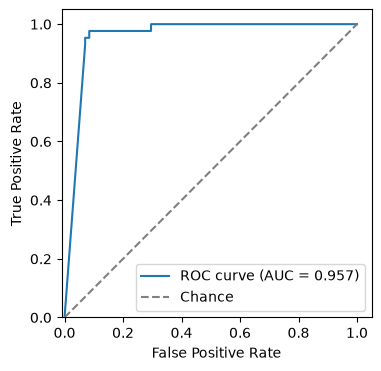

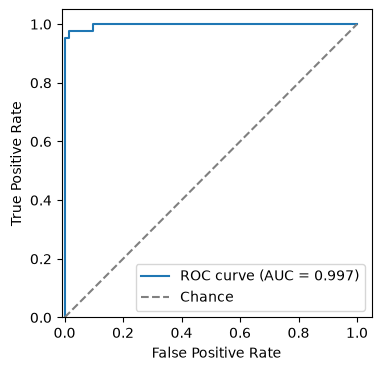

Test AUC no regularization: 0.9567638388470358
Test AUC with L2: 0.99737962659679


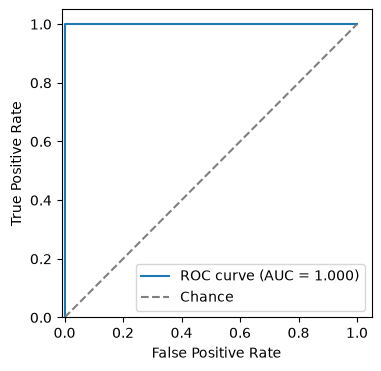

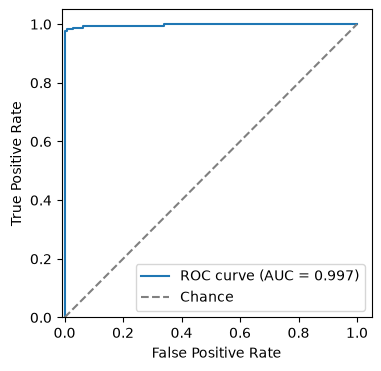

Train AUC no regularization: 1.0
Train AUC with L2: 0.9974138287747756


In [223]:
# load necessary evaluation metrics
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve, auc

## ❓YOUR CODE HERE
## Write function to make a ROC curve and calculate AUC
def plot_my_roc_curve(model, X_data, y_values):
  # write your code here
  # predict probabilities of the positive class (malignant tumor)
  y_probs = model.predict_proba(X_data)[:, 1]

  # Compute ROC curve and AUC
  fpr, tpr, thresholds = roc_curve(y_values, y_probs)
  roc_auc = auc(fpr, tpr)

  ## plotting
  plt.figure(figsize = (4,4))
  # Display ROC curve and AUC
  plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")

  # add a line for where random chance is on the ROC curve
  plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
  
  # change the limits of the x and y axis so you can see the full plot
  plt.xlim([-0.01, 1.05])
  plt.ylim([0.0, 1.05])
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.legend(loc="lower right")
  plt.show()

  return roc_auc

# Apply this function to your test data
test_auc_noreg = plot_my_roc_curve(logReg, XTestScaled, yTest)
test_auc_l2 = plot_my_roc_curve(l2Reg, XTestScaled, yTest)
print(f"Test AUC no regularization: {test_auc_noreg}")
print(f"Test AUC with L2: {test_auc_l2}")

## Apply this function to your training data (unusual, but we are comparing in this assignment)
train_auc_noreg = plot_my_roc_curve(logReg, XTrainScaled, yTrain)
train_auc_l2 = plot_my_roc_curve(l2Reg, XTrainScaled, yTrain)
print(f"Train AUC no regularization: {train_auc_noreg}")
print(f"Train AUC with L2: {train_auc_l2}")


⭐ 4.4.2 Briefly compare and contrast your ROC curves and AUC on both models across training and testing data.

🍓Answer:

## Feedback

❓What's one thing you learned in this assignment?

✅ Answer:

❓ What do you wish had been different about this assignment?

✅ Answer: